In [1]:

print("Insta Cart Market Analysis Project")

Insta Cart Market Analysis Project


In [2]:

import os

# Searching for files
for dirname, subdirs, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'orders.csv':
            print("Path is:")
            print(dirname + '/')

Path is:
/kaggle/input/datasets/ruchika221/dataset4/


In [3]:

import os

path = '/kaggle/input/datasets/ruchika221/dataset4/'

print("Checking raw file sizes on disk...\n")


files = [
    'order_products__prior.csv', 
    'order_products__train.csv',
    'orders.csv', 
    'products.csv',
    'departments.csv',
    'aisles.csv'
]

for file in files:
    full_path = os.path.join(path, file)
    if os.path.exists(full_path):
        size_in_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f"{file}: {size_in_mb:.2f} MB")
    else:
        print(f" Could not find {file}")

Checking raw file sizes on disk...

order_products__prior.csv: 550.80 MB
order_products__train.csv: 23.54 MB
orders.csv: 103.92 MB
products.csv: 2.07 MB
departments.csv: 0.00 MB
aisles.csv: 0.00 MB


In [4]:


import pandas as pd

path = '/kaggle/input/datasets/ruchika221/dataset4/'

def simple_downcast(df, name="Dataframe"):
    """Uses built-in Pandas functions to shrink memory size and prints the savings."""
    # Calculate starting memory in Megabytes
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"{name} original size: {start_mem:.2f} MB")
    
    # Downcast integers
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
        
    # Downcast floats
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
        
    # Calculate final memory and the percentage saved
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"{name} new size: {end_mem:.2f} MB")
    print(f"Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%\n")
    
    return df

print("Loading and compressing data...\n")
orders = simple_downcast(pd.read_csv(path + 'orders.csv'), "Orders")
prior_orders = simple_downcast(pd.read_csv(path + 'order_products__prior.csv'), "Prior Orders")
products = simple_downcast(pd.read_csv(path + 'products.csv'), "Products")

print("Created  3 new dataframes which are compressed version of old dataframes")

print("1. orders df is compressed version of orders.csv  ")
print("2. prior_orders df is compressed version of order_products__prior.csv ")
print("3. products df is compressed version of products.csv")

print("\nData loaded successfully.")

Loading and compressing data...

Orders original size: 182.71 MB
Orders new size: 75.04 MB
Decreased by 58.9%

Prior Orders original size: 989.82 MB
Prior Orders new size: 340.25 MB
Decreased by 65.6%

Products original size: 1.52 MB
Products new size: 0.71 MB
Decreased by 53.1%

Created  3 new dataframes which are compressed version of old dataframes
1. orders df is compressed version of orders.csv  
2. prior_orders df is compressed version of order_products__prior.csv 
3. products df is compressed version of products.csv

Data loaded successfully.


In [5]:

import pandas as pd
import os

print("Starting data inspection.")


print("1. ORDERS TABLE")
print(f"Shape: {orders.shape}")
display(orders.head(3)) 


Starting data inspection.
1. ORDERS TABLE
Shape: (3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


* order id: order id of product (the digital receipt number)

* user id : 1 user id (The unique ID number identifying the specific customer who made the purchase.)
* Eval set indicates if this order belongs to the historical tracking data (prior) or the final evaluation data (test).

* order_number the sequential order count for that user

* order_dow : The day on which the order was placed

* order_hour_of_day : The exact hour of the day the customer placed the order

* days_since_prior_order: How many days passed since this customer's last purchase



In [6]:

print("\n2. PRIOR ORDERS TABLE (Historical Baskets)")
print(f"Shape: {prior_orders.shape}")
display(prior_orders.head(3))




2. PRIOR ORDERS TABLE (Historical Baskets)
Shape: (32434489, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


* add_to_cart_order: exact sequence the user added these items to their digital cart.
  
* reordered : has the user bought this item before -- 1 : Yes 0 : No


In [7]:

print("\n3. PRODUCTS TABLE")
print(f"Shape: {products.shape}")
display(products.head(3))




3. PRODUCTS TABLE
Shape: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


* aisle_id : Inside dept there can be different aisle like Milk , icecream etc.
* department_id : dept id like department like Dairy 

In [8]:


print("\n4. TRAIN ORDERS TABLE")
train_peek = pd.read_csv(os.path.join(path, 'order_products__train.csv'), nrows=3)
display(train_peek)  




4. TRAIN ORDERS TABLE


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0


In [9]:

print("\n5. DEPARTMENTS & AISLES (Product Groupings for Campaigns)")
departments = pd.read_csv(os.path.join(path, 'departments.csv'))
aisles = pd.read_csv(os.path.join(path, 'aisles.csv'))
display(departments.head(2))
display(aisles.head(2))


5. DEPARTMENTS & AISLES (Product Groupings for Campaigns)


,department_id,department
0,1,frozen
1,2,other


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses


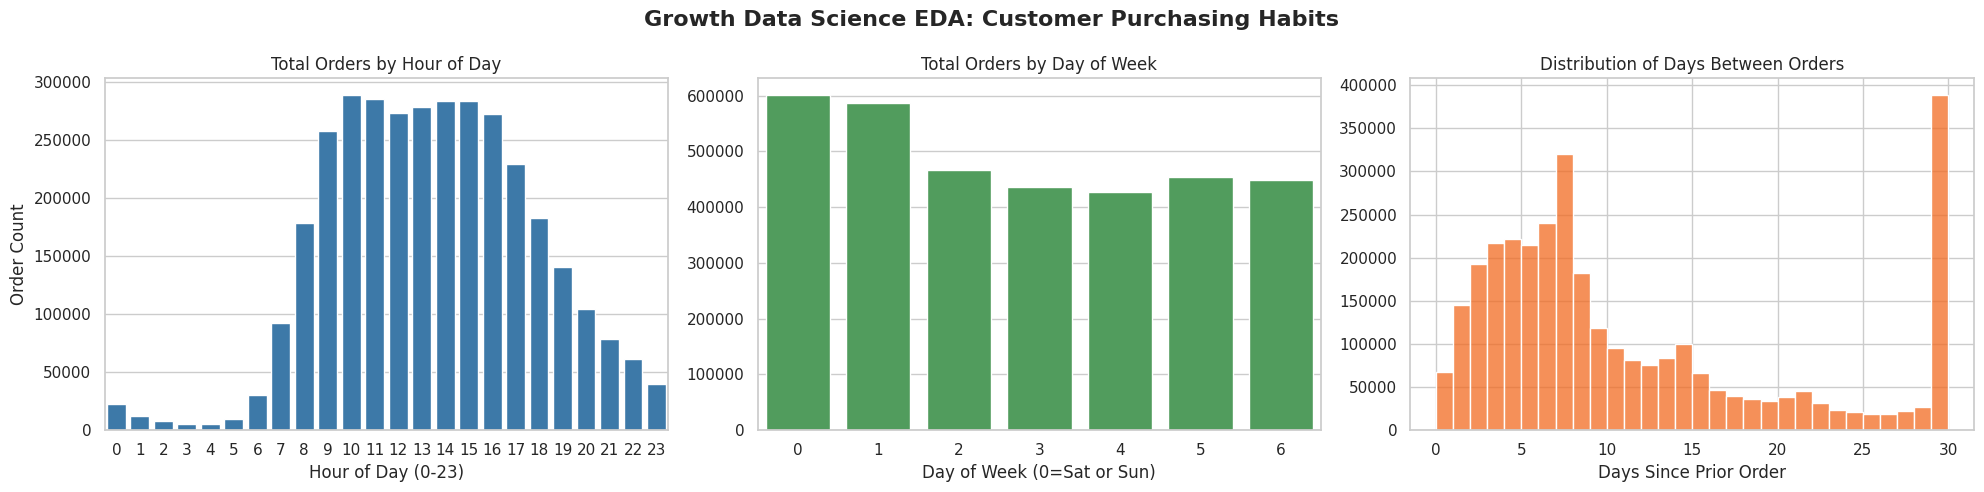

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Growth Data Science EDA: Customer Purchasing Habits', fontsize=16, weight='bold')


#  What time of day is the busiest?
# It helps plan delivery fleet capacity.

sns.countplot(data=orders, x='order_hour_of_day', color='#2b7bba', ax=axes[0])
axes[0].set_title('Total Orders by Hour of Day')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Order Count')


#  Which day of the week gets the most traffic?
# It dictates when to launch promotional campaigns.

sns.countplot(data=orders, x='order_dow', color='#45a854', ax=axes[1])
axes[1].set_title('Total Orders by Day of Week')
axes[1].set_xlabel('Day of Week (0=Sat or Sun)')
axes[1].set_ylabel('')

#  How long do people wait before ordering again?
# It defines the baseline for "Churn" alerts.

sns.histplot(data=orders, x='days_since_prior_order', bins=30, color='#f26b21', ax=axes[2], kde=False)
axes[2].set_title('Distribution of Days Between Orders')
axes[2].set_xlabel('Days Since Prior Order')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


- **9 to 5 PM is the most busy orderSunday and Monday has the highest number of order**

- **As per third histogram , a huge number of user shops after a week.More than that user shop after 30days they should be sent retention msg.**

- **The tracker is capped at 30 days, creating a bucket for anyone who hasn't ordered in a month or longer. Seeing nearly 4 lakh orders sitting in this 30-day bucket is a huge churn problem.**



**Feature Engineering**

In [11]:

# How popular  is each product across the entire app?

# Ordering product group by then counting how many times each group appears ,taking the mean of how many
# times these groups where ordered each time
# Example : Milk was ordered 10,000 times that is the count,  reordered rate is 0.7 then it means 70% of
# time milk was re-ordered




print("1. Checking popularity of products")
product_features = prior_orders.groupby('product_id').agg(
    total_purchases=('reordered', 'count'),
    reorder_rate=('reordered', 'mean') # Percentage of times this was a repeat purchase
).reset_index()


print('''\n PRODUCT FEATURE: Product feature is a dataframe which shows how many times each product was purchased along wi
percentage time it is repeat purchase''')


print("2. Mapping Users to their Items.")
# Attaching the user_id to every single product ever ordered
# Creating a new table in whoch there will be two colums order id and their user's id.

prior_user_orders = prior_orders.merge(orders[['order_id', 'user_id']], on='order_id', how='left')

# how much a specific person loves a specific item.
# USER PRODUCT AFFINITY

print("\n PRIOR ORDER :Prior order was a dataframe whhich was downcast version of order_products__prior.csv ")
print('''\n PRIOR_USER_ORDERS: prior_user_orders is a dataframe which has all the order id against their user id''')


print("\n 3. Calculating User-Product Affinity.")
# How many times has a specific user bought a specific product?
# Using the table that I created in previous step again using grouo by. First grouping by user_id then
# by product_id. Then we count how many of these items were bought how many times


user_product_features = prior_user_orders.groupby(['user_id', 'product_id']).agg(
    times_bought=('reordered', 'count')
).reset_index()


print('''\nUSER_PRODUCT_FEATURES: We used the df just created prior_user_orders and using that create a new dataframe  in which
we have user id and all the product they purchased along with percentage of time they are purchasing it
again''')

user_features = orders.groupby('user_id').agg(
    total_orders=('order_number', 'max'),
    mean_days_between_orders=('days_since_prior_order', 'mean')
).reset_index()

print('''"USER_FEATURES : User feature is a df that we created using orders df in which we have each user id
against their all  orders and the avg number of days between their two order''')

display(user_product_features.head()) 

1. Checking popularity of products

 PRODUCT FEATURE: Product feature is a dataframe which shows how many times each product was purchased along wi
percentage time it is repeat purchase
2. Mapping Users to their Items.

 PRIOR ORDER :Prior order was a dataframe whhich was downcast version of order_products__prior.csv 

 PRIOR_USER_ORDERS: prior_user_orders is a dataframe which has all the order id against their user id

 3. Calculating User-Product Affinity.

USER_PRODUCT_FEATURES: We used the df just created prior_user_orders and using that create a new dataframe  in which
we have user id and all the product they purchased along with percentage of time they are purchasing it
again
"USER_FEATURES : User feature is a df that we created using orders df in which we have each user id
against their all  orders and the avg number of days between their two order


,user_id,product_id,times_bought
0,1,196,10
1,1,10258,9
2,1,10326,1
3,1,12427,10
4,1,13032,3


In [12]:
display(product_features.head())

,product_id,total_purchases,reorder_rate
0,1,1852,0.613391
1,2,90,0.133333
2,3,277,0.732852
3,4,329,0.446809
4,5,15,0.600000


In [13]:

display(user_features.head())

,user_id,total_orders,mean_days_between_orders
0,1,11,19.000000
1,2,15,16.285715
2,3,13,12.000000
3,4,6,17.000000
4,5,5,11.500000


In [14]:

display(user_product_features.head())

,user_id,product_id,times_bought
0,1,196,10
1,1,10258,9
2,1,10326,1
3,1,12427,10
4,1,13032,3


In [15]:

# Creating a safe copy of table to prevent memory overlap errors.

feature_matrix = user_product_features.copy() 

In [16]:
feature_matrix.head()

,user_id,product_id,times_bought
0,1,196,10
1,1,10258,9
2,1,10326,1
3,1,12427,10
4,1,13032,3


**USER_PRODUCT_FEATURES: We used the df just created prior_user_orders and using that create a new dataframe  in which we have user id and all the product they purchased along with percentage of time they are purchasing it**

In [17]:
# Attaching the user's overall behavioral profile to give the algorithm


#This will be basically merge of user_features and user_product_features df over user_id 
feature_matrix = feature_matrix.merge(user_features, on='user_id', how='left')                             

In [18]:

#Now merging this feature matrix with df product_features
feature_matrix = feature_matrix.merge(product_features, on='product_id', how='left') 

In [19]:

feature_matrix.head()

,user_id,product_id,times_bought,total_orders,mean_days_between_orders,total_purchases,reorder_rate
0,1,196,10,11,19.0,35791,0.776480
1,1,10258,9,11,19.0,1946,0.713772
2,1,10326,1,11,19.0,5526,0.652009
3,1,12427,10,11,19.0,6476,0.740735
4,1,13032,3,11,19.0,3751,0.657158


In [20]:

train_orders = pd.read_csv(path + 'order_products__train.csv')

In [21]:

train_orders.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [22]:

train_orders = train_orders.merge(orders[['order_id', 'user_id']], on='order_id', how='left')

In [23]:

train_orders = train_orders[['user_id', 'product_id', 'reordered']]

In [24]:

train_orders.head()

,user_id,product_id,reordered
0,112108,49302,1
1,112108,11109,1
2,112108,10246,0
3,112108,49683,0
4,112108,43633,1


In [25]:

feature_matrix = feature_matrix.merge(train_orders, on=['user_id', 'product_id'], how='left')

In [26]:

feature_matrix.head() 

,user_id,product_id,times_bought,total_orders,mean_days_between_orders,total_purchases,reorder_rate,reordered
0,1,196,10,11,19.0,35791,0.776480,1.0
1,1,10258,9,11,19.0,1946,0.713772,1.0
2,1,10326,1,11,19.0,5526,0.652009,NaN
3,1,12427,10,11,19.0,6476,0.740735,NaN
4,1,13032,3,11,19.0,3751,0.657158,1.0


In [27]:

feature_matrix['reordered'] = feature_matrix['reordered'].fillna(0)

In [28]:

display(feature_matrix.head())

,user_id,product_id,times_bought,total_orders,mean_days_between_orders,total_purchases,reorder_rate,reordered
0,1,196,10,11,19.0,35791,0.776480,1.0
1,1,10258,9,11,19.0,1946,0.713772,1.0
2,1,10326,1,11,19.0,5526,0.652009,0.0
3,1,12427,10,11,19.0,6476,0.740735,0.0
4,1,13032,3,11,19.0,3751,0.657158,1.0


In [29]:

feature_matrix = feature_matrix.set_index(['user_id', 'product_id'])

In [30]:

feature_matrix['reordered'] = feature_matrix['reordered'].astype('int8')

In [31]:

# Separate the features (X) and the target (y)
X = feature_matrix.drop(['reordered'], axis=1)
y = feature_matrix['reordered']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (13307953, 5)
Target (y) shape: (13307953,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into Train and Test sets successfully.")


import xgboost as xgb

# Initialize the model
model = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    n_estimators=100,            # Number of trees to build
    max_depth=5,                 # How complex each tree can be
    learning_rate=0.1
)

# Train the model
print("Training the model...")
model.fit(X_train, y_train)
print("Training complete!")

y_pred_baseline = model.predict(X_test) 

Data split into Train and Test sets successfully.
Training the model...
Training complete!


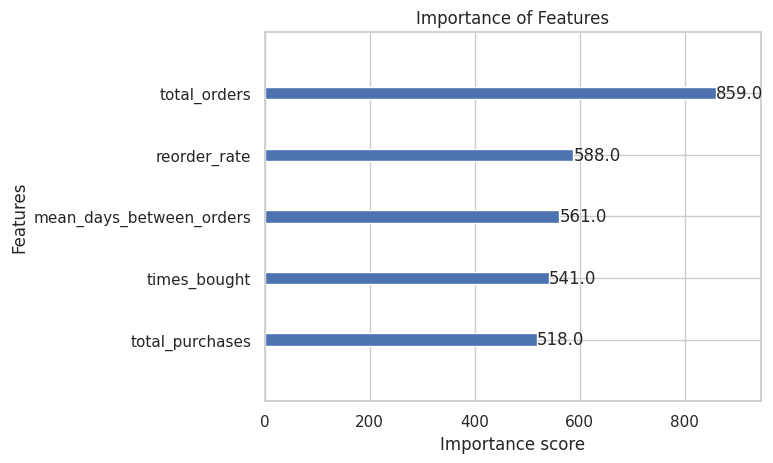

In [33]:

import matplotlib.pyplot as plt 

# Plotting the Importance of each feature 
xgb.plot_importance(model) 
plt.title("Importance of Features")
plt.show()  

In [34]:

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_baseline ,  output_dict=True)

clean_report = pd.DataFrame(report_dict).iloc[:-1, :2].T 

print("--- MODEL PERFORMANCE ---")
display(clean_report)

--- MODEL PERFORMANCE ---


,precision,recall,f1-score
0,0.937916,0.999690,0.967818
1,0.520471,0.005055,0.010012


--- MODEL PERFORMANCE REPORT ---


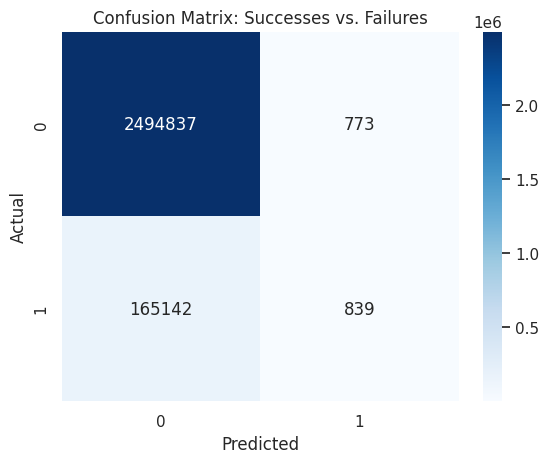

In [35]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

print("--- MODEL PERFORMANCE REPORT ---")



cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Successes vs. Failures')
plt.show()

In [36]:

model2 = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=15,  # Giving the '1s' 15 times more importance
    eval_metric='logloss',
    n_estimators=100,
    max_depth=5
)



In [37]:

# Train the model
print("Training the new model...") 
model2.fit(X_train, y_train)
print("Training complete!") 
y_pred_2 = model2.predict(X_test) 

Training the new model...
Training complete!


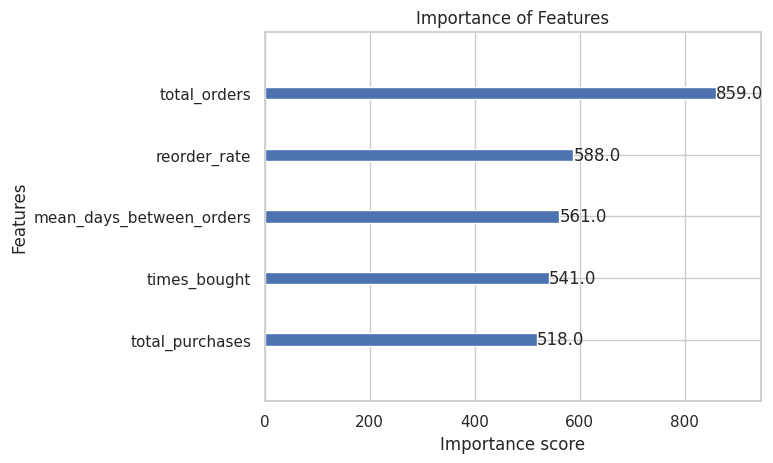

In [38]:

import matplotlib.pyplot as plt

# Plotting the Importance of each feature  
xgb.plot_importance(model)
plt.title("Importance of Features") 
plt.show() 

In [39]:

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_2, output_dict=True)


clean_report = pd.DataFrame(report_dict).iloc[:-1, :2].T 

print("--- REFINED MODEL PERFORMANCE ---")
display(clean_report)

--- REFINED MODEL PERFORMANCE ---


,precision,recall,f1-score
0,0.972960,0.724675,0.830661
1,0.144141,0.697188,0.238892


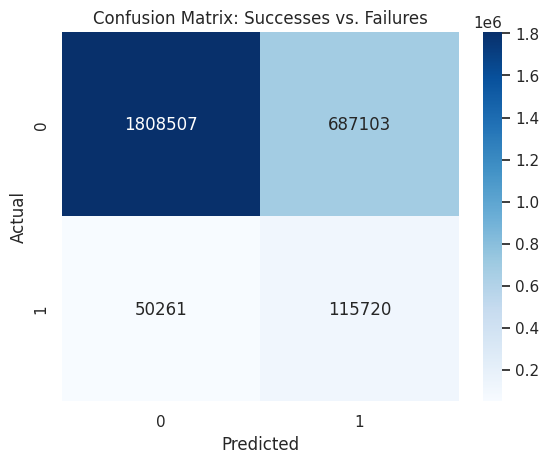

In [40]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


y_pred = model.predict(X_test)




cm = confusion_matrix(y_test, y_pred_2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Successes vs. Failures')
plt.show()

In [41]:
print(X_test.columns.tolist())

['times_bought', 'total_orders', 'mean_days_between_orders', 'total_purchases', 'reorder_rate']


In [42]:
print("Index names:", feature_matrix.index.names)

Index names: ['user_id', 'product_id']


In [43]:
X_test.head()

,,times_bought,total_orders,mean_days_between_orders,total_purchases,reorder_rate
user_id,product_id,,,,,
163834,26283,3,16,15.800000,18906,0.583148
125629,28204,2,12,14.272727,89632,0.711922
182247,14183,3,5,23.750000,2794,0.614889
174134,20169,1,14,8.076923,3054,0.527505
107989,14429,1,52,6.588235,2761,0.228178


In [44]:
# 1. Generate the probability of reordering (Class 1)
# model.predict_proba returns [prob_0, prob_1], so we take [:, 1]


# We are predicting probability for all the item bought by all the individual user and then calculating
# what are the chances that they will buy that product

# For example let's say there are 2 users - User A , User B 
# User A bought milk , eggs 
# User B bought Fruits , veggies , cold drinks

# so this predict_proba will create a 2D matrix for each user lilke for 
#  [[0.9 , 0.1   ]  [ 0.4, 0.6]  [ 0.3 ,0.7] [0.4,0.6] [0.35 , 0.65]]


# First two 1D matrix is for user A and last three user matrix B 
# So [0.9 , 0.1 ] -- Milk [ 0.4, 0.6] -- Eggs
# [ 0.3 ,0.7] -- Fruits , [0.4,0.6] -- veggies ,   [0.35 , 0.65]  -- cold drinks

# We are using [: , 1] because we are doing binary logistic so we need only one column because 
# other column value can be found by 1 - value 


 
propensity_scores = model.predict_proba(X_test)[:, 1]  


# X_test.index() is a multi index df so we want only user id from that columns
# that is what we do in 
# 'User_ID': X_test.index.get_level_values('user_id'), 
# similarly we do that for  'Product_ID'
# and we use propensity and get a new df and print it

                    
# 2. Create the results table by pulling IDs directly from the Index levels
results = pd.DataFrame({
    'User_ID': X_test.index.get_level_values('user_id'), 
    'Product_ID': X_test.index.get_level_values('product_id'),
    'Propensity_Score': propensity_scores
})

# 3. Sort by highest score to find the "Power Shoppers"
results_sorted = results.sort_values(by='Propensity_Score', ascending=False)

print("CUSTOMER PROPENSITY TABLE (TOP 10)")
display(results_sorted.head(10))

CUSTOMER PROPENSITY TABLE (TOP 10)


,User_ID,Product_ID,Propensity_Score
477032,46466,23106,0.664669
2331246,179364,36865,0.661979
817286,151941,24852,0.658796
1259622,46466,5077,0.658494
1841460,179364,1712,0.658448
355360,164673,24852,0.652462
845561,52307,21137,0.649972
1576977,102195,13176,0.644048
2589770,74814,13176,0.644048
1249038,78409,13176,0.641037


In [45]:
final_results = pd.merge(
    results_sorted, 
    products[['product_id', 'product_name']], 
    left_on='Product_ID', 
    right_on='product_id', 
    how='left'
) 

In [46]:
print(products.columns.tolist())

['product_id', 'product_name', 'aisle_id', 'department_id']


In [47]:
products['product_id'] = products['product_id'].astype(int)
results_sorted['Product_ID'] = results_sorted['Product_ID'].astype(int)

product_dict = dict(zip(products['product_id'], products['product_name']))

results_sorted['Product_Name'] = results_sorted['Product_ID'].map(product_dict)

final_table = results_sorted[['User_ID', 'Product_ID', 'Product_Name', 'Propensity_Score']]

print("--- FINAL NOON TARGETING LIST ---")
display(final_table.head(10))

--- FINAL NOON TARGETING LIST ---


,User_ID,Product_ID,Product_Name,Propensity_Score
477032,46466,23106,Pomegranate on the Bottom Non-Fat Greek Yogurt,0.664669
2331246,179364,36865,Non Fat Raspberry Yogurt,0.661979
817286,151941,24852,Banana,0.658796
1259622,46466,5077,100% Whole Wheat Bread,0.658494
1841460,179364,1712,Pomegranate Blueberry Pistachio Plus Antioxida...,0.658448
355360,164673,24852,Banana,0.652462
845561,52307,21137,Organic Strawberries,0.649972
1576977,102195,13176,Bag of Organic Bananas,0.644048
2589770,74814,13176,Bag of Organic Bananas,0.644048
1249038,78409,13176,Bag of Organic Bananas,0.641037


In [49]:
print("ksdk")

ksdk
